In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

# The star of the show.
import bayesflow as bf

from functools import partial

In [6]:
# Restrict long numerics
np.set_printoptions(suppress=True)

# Ensure repeatable randomness
RNG = np.random.default_rng(2024)

# Posterior Estimation for Autoregressive Model

In this notebook, we use BayesFlow for simulation-based posterior estimation of a simple autoregressive model AR(1). The model is defined as follows:

$$
\begin{align}
    \alpha &\sim \mathcal{N}(0, 0.01), \\
    \beta &\sim \mathcal{N}(0, 1), \\
    \sigma &\sim \mathrm{Gamma}(1, 1), \\
    y_t &= \mathcal{N}(\alpha + \beta\,y_{t-1}, \sigma)\quad\text{for}\quad t = 1,\dots,T.
\end{align}
$$

## Priors

In [7]:
PARAM_NAMES = [r"$\alpha$", r"$\beta$", r"$\sigma$"]

In [8]:
def prior_fun(rng=None):
    """ 
    Samples random parameter configuration from the prior distribution. 
    """
    if rng is None:
        rng = np.random.default_rng()
    
    alpha = rng.normal(0, 0.01)
    beta = rng.normal(0, 1)
    sigma = rng.gamma(1, 1)

    return np.r_[alpha, beta, sigma]

In [9]:
prior = bf.simulation.Prior(prior_fun=prior_fun, param_names=PARAM_NAMES)

In [10]:
prior(batch_size=5)

{'prior_draws': array([[-0.01977998, -0.11259847,  1.19344413],
        [ 0.00862216, -0.46029553,  0.58379745],
        [-0.00323453,  0.41271146,  1.32810025],
        [-0.00464101,  0.29843856,  0.76019232],
        [ 0.00146616, -0.4587426 ,  1.49990747]]),
 'batchable_context': None,
 'non_batchable_context': None}

In [11]:
prior_mean, prior_stds = prior.estimate_means_and_stds()
prior_mean, prior_stds

(array([[-0.00015237, -0.0205283 ,  1.00361616]]),
 array([[0.01014645, 0.96941538, 1.01082693]]))

## Simulator

In [12]:
def simulator_fun(theta, num_timesteps=100, rng=None, *args):
    """ 
    Simulator for the autoregressive model AR(1). 

    Parameters
    ----------
    theta       : np.array of size (3,)
        Parameters for the AR(1) model: intercept (alpha), slope (beta), and scale (sigma).
    num_obs     : int
        Number of generated data points.
    rng         : np.random
        Random number generator. If unspecified, default generator is used.

    Returns
    -------
    data        : np.array of size (num_obs, )
        Generated time-series data.
    """

    if rng is None:
        rng = np.random.default_rng()

    alpha, beta, scale = theta

    data = np.zeros((num_timesteps, 1))
    
    for i in range(1, num_timesteps):
        data[i] = rng.normal(loc=alpha + beta * data[i-1], scale=scale)

    return data

In [13]:
# Define the number of observation
N_TIMESTEPS = 101

## Generative Model

In [14]:
def model_fun(rng=None):

    if rng is not None:
        rng = np.random.default_rng()

    theta = prior_fun()
    y = simulator_fun(theta, rng=rng)
    return theta, y

In [15]:
theta, y = model_fun(rng=RNG)

In [16]:
# Shape is very important. In this notebook, we would keep track of the shapes throughout.
y.shape

(100, 1)

In [17]:
def plot_simulation(data):
    num_timesteps, data_dim = data.shape

    t = np.arange(1, num_timesteps + 1)

    f, ax = plt.subplots(1, 1, figsize=(8, 6))

    ax = sns.lineplot(x=t, y=data[:, 0], color='#007396')
    ax.set(xlabel="Timestep", ylabel="Result")

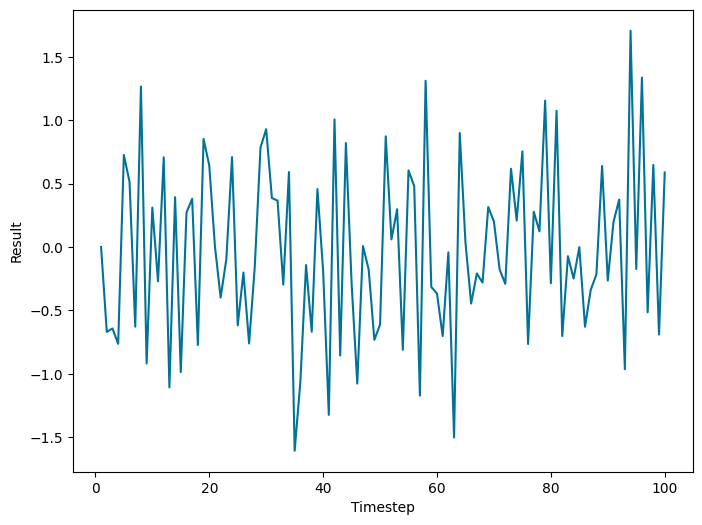

In [18]:
plot_simulation(y)

In [19]:
ar_model = bf.simulation.GenerativeModel(
    prior=partial(prior_fun, rng=RNG),
    simulator=partial(simulator_fun, num_timesteps=N_TIMESTEPS),
    name="AR",
    simulator_is_batched=False
)

INFO:root:Performing 2 pilot runs with the AR model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 3)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 101, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


#### Prior Predictive Check

In [20]:
test = ar_model(batch_size=5)

In [21]:
test['sim_data'].shape

(5, 101, 1)

<Axes: ylabel='Density'>

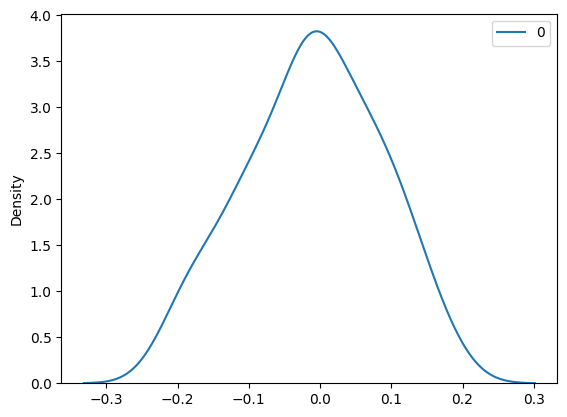

In [22]:
sns.kdeplot(test["sim_data"][4])

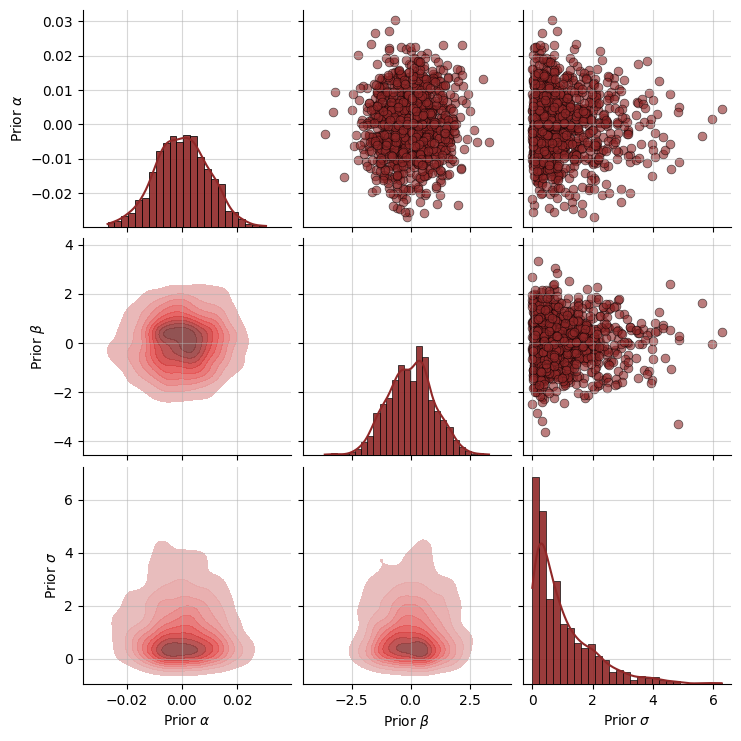

In [23]:
f = prior.plot_prior2d(n_samples=1000)

## Configuration and Time Embedding

In [24]:
data = test['sim_data']
data.shape

(5, 101, 1)

In [25]:
def configurator(input_dict):
    from sklearn.preprocessing import MinMaxScaler
    """
    Function to configure the simulated quantities (i.e., simulator outputs)
    into a neural network-friendly (BayesFlow) format.
    """
    # Prepare placeholder dict
    out_dict = {}

    # Get parameters from input_dict
    params = input_dict['prior_draws']
    out_dict['parameters'] = params

    # Get data from input_dict
    data = input_dict['sim_data']

    # Remove any values containing +inf, -inf, and nan
    finite = np.all(np.isfinite(data), axis=(1, 2))
    data = data[finite]

    # Scale the data (using min-max scaling may not be a good idea)
    scaler = MinMaxScaler()
    data[:,:,0] = scaler.fit_transform(data[:,:,0])

    # Add time embedding to data
    batch_size, num_timesteps, data_dim = data.shape
    t = np.linspace(0, 1, num_timesteps)
    t_batched = np.tile(t[np.newaxis, :, np.newaxis], (batch_size, 1, 1))

    out_dict['summary_conditions'] = np.concatenate((data, t_batched), axis=-1)

    return out_dict

In [26]:
sim = ar_model(50)

In [27]:
out_dict = configurator(sim)

In [28]:
# Inspect the time embedding
out_dict['summary_conditions']

array([[[0.        , 0.        ],
        [0.39095947, 0.01      ],
        [0.7312928 , 0.02      ],
        ...,
        [0.0000022 , 0.98      ],
        [1.        , 0.99      ],
        [0.00000157, 1.        ]],

       [[0.        , 0.        ],
        [0.53159183, 0.01      ],
        [0.69738496, 0.02      ],
        ...,
        [0.0000022 , 0.98      ],
        [1.        , 0.99      ],
        [0.00000157, 1.        ]],

       [[0.        , 0.        ],
        [0.49325616, 0.01      ],
        [0.7279005 , 0.02      ],
        ...,
        [0.0000022 , 0.98      ],
        [1.        , 0.99      ],
        [0.00000157, 1.        ]],

       ...,

       [[0.        , 0.        ],
        [0.48652887, 0.01      ],
        [0.70882572, 0.02      ],
        ...,
        [0.0000022 , 0.98      ],
        [1.        , 0.99      ],
        [0.00000157, 1.        ]],

       [[0.        , 0.        ],
        [0.42084033, 0.01      ],
        [0.7513031 , 0.02      ],
        .

## Neural Approximator

We use ``TimeSeriesTransformer`` as our summary network.

In [29]:
# Would be interesting to do a model comparison between using SequenceNetwork and TimeSeriesTransformer as summary net.
summary_net = bf.summary_networks.TimeSeriesTransformer(input_dim=2, summary_dim=5)

In [30]:
# How do we know what the right coupling setting is?
inference_net = bf.inference_networks.InvertibleNetwork(
    num_params=len(prior.param_names), 
    num_coupling_layers=6,
    coupling_settings={
        'kernel_regularizer': tf.keras.regularizers.l2(1e-4),
        'dropout_prob': 0.10
    }
)

In [31]:
amortizer = bf.amortizers.AmortizedPosterior(inference_net=inference_net, summary_net=summary_net, name="ar_amortizer")

In [32]:
sim = ar_model(100)
sim['sim_data'].shape

(100, 101, 1)

In [33]:
out = configurator(sim)
out['summary_conditions'].shape

(100, 101, 2)

## Training Phase

In [34]:
trainer = bf.trainers.Trainer(
    generative_model=ar_model, 
    amortizer=amortizer, 
    configurator=configurator 
)

INFO:root:Performing a consistency check with provided components...



INFO:root:Done.


In [35]:
amortizer.summary()

Model: "ar_amortizer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 invertible_network (Invert  multiple                  424044    
 ibleNetwork)                                                    
                                                                 
 time_series_transformer (T  multiple                  59357     
 imeSeriesTransformer)                                           
                                                                 
Total params: 483401 (1.84 MB)
Trainable params: 483365 (1.84 MB)
Non-trainable params: 36 (144.00 Byte)
_________________________________________________________________


In [36]:
history = trainer.train_online(epochs=30, iterations_per_epoch=200, batch_size=32)

Training epoch 1:   0%|          | 0/200 [00:00<?, ?it/s]

Training epoch 30: 100%|██████████| 200/200 [00:40<00:00,  4.98it/s, Epoch: 30, Iter: 200,Loss: -0.505,W.Decay: 0.033,Avg.Loss: -0.346,Avg.W.Decay: 0.034,LR: 2.98E-11]


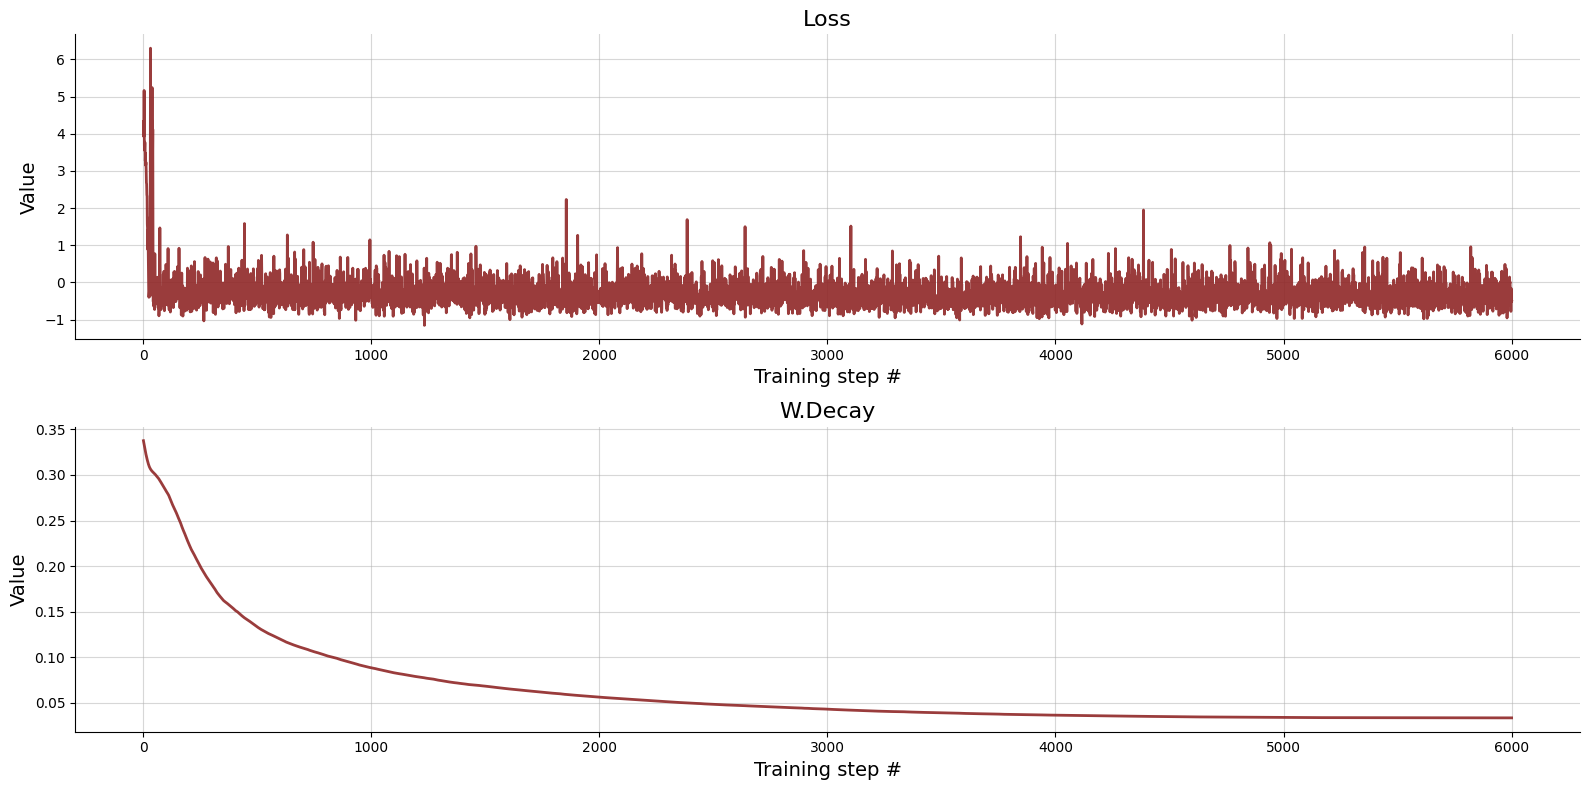

In [37]:
f = bf.diagnostics.plot_losses(history)

## Validation Phase

In [38]:
# Simulate a batch of data for validation
val = trainer.configurator(ar_model(50))
val['summary_conditions'].shape

(50, 101, 2)

In [39]:
# Sample from posterior
posterior_samples = amortizer.sample(val, n_samples=1000)
posterior_samples.shape

(50, 1000, 3)

### Posterior Predictive Check

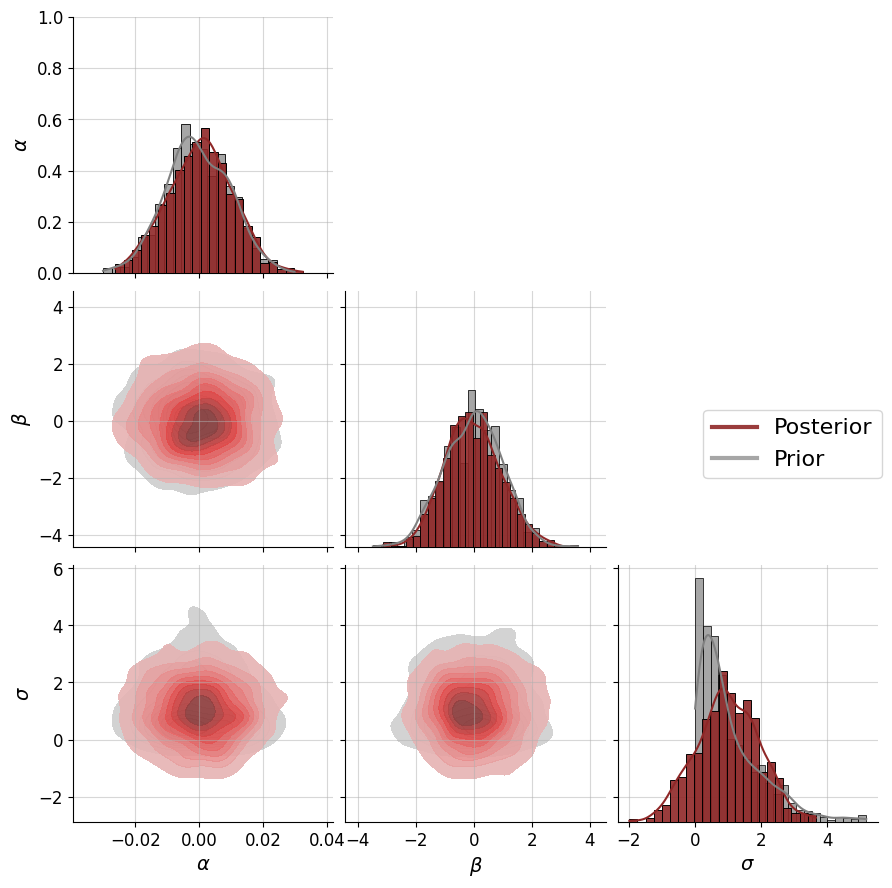

In [40]:
f = bf.diagnostics.plot_posterior_2d(
    posterior_samples[0],
    trainer.generative_model.prior,
    param_names=PARAM_NAMES
)

### Parameter Recovery

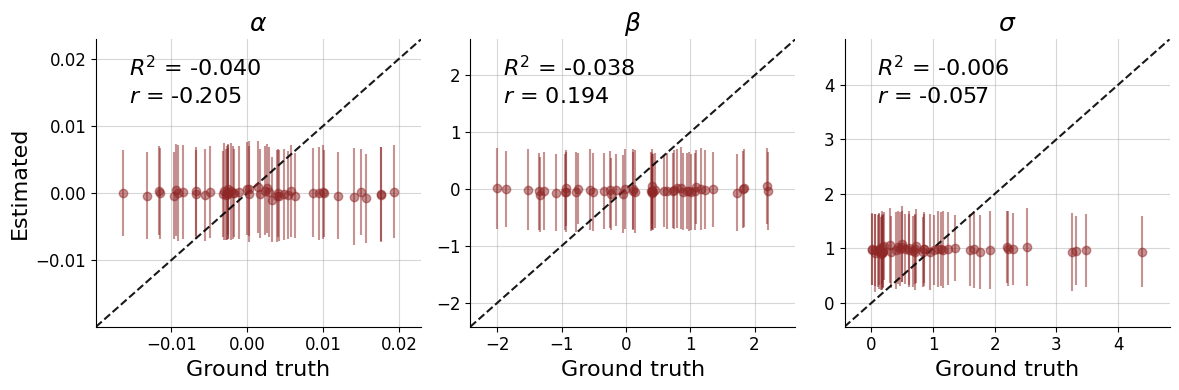

In [41]:
f = bf.diagnostics.plot_recovery(
    posterior_samples,
    val["parameters"],
    param_names=PARAM_NAMES
)

Nothing is learned. Something about the configurator is still wrong.